In [ ]:
import tensorflow

In [ ]:
print(tensorflow.__version__)

2.20.0


In [ ]:
#mounting the google drive for importing the data
from google.colab import drive
drive.mount('/content/gdrive')

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


In [ ]:
!1s gdrive/MyDrive

/bin/bash: line 1: 1s: command not found


In [ ]:
! unzip gdrive/MyDrive/pneumonia-xray-images.zip

Streaming output truncated to the last 5000 lines.
  inflating: train/normal/IM-0435-0001-0001.jpeg  
  inflating: train/normal/IM-0435-0001.jpeg  
  inflating: train/normal/IM-0437-0001-0001.jpeg  
  inflating: train/normal/IM-0437-0001-0002.jpeg  
  inflating: train/normal/IM-0437-0001.jpeg  
  inflating: train/normal/IM-0438-0001.jpeg  
  inflating: train/normal/IM-0439-0001-0001.jpeg  
  inflating: train/normal/IM-0439-0001-0002.jpeg  
  inflating: train/normal/IM-0439-0001.jpeg  
  inflating: train/normal/IM-0440-0001.jpeg  
  inflating: train/normal/IM-0441-0001.jpeg  
  inflating: train/normal/IM-0442-0001.jpeg  
  inflating: train/normal/IM-0444-0001.jpeg  
  inflating: train/normal/IM-0445-0001.jpeg  
  inflating: train/normal/IM-0446-0001.jpeg  
  inflating: train/normal/IM-0447-0001.jpeg  
  inflating: train/normal/IM-0448-0001.jpeg  
  inflating: train/normal/IM-0449-0001.jpeg  
  inflating: train/normal/IM-0450-0001.jpeg  
  inflating: train/normal/IM-0451-0001.jpeg  
  in

In [ ]:
#importing the libraries I
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os

In [ ]:
DataDir = r"train/"

In [ ]:
CATEGORIES = ["normal", "opacity"]

In [ ]:
! ls test

normal	opacity


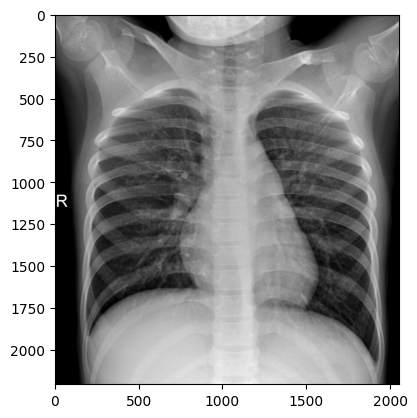

In [ ]:
# converting the images into grayscale

for i in CATEGORIES:
    path = os.path.join(DataDir, i)

    for img in os.listdir(path):

        img_array = cv2.imread(
            os.path.join(path, img),
            cv2.IMREAD_GRAYSCALE
        )

        plt.imshow(img_array, cmap='gray')
        plt.show()

        break

    break

In [ ]:
img_size = 100

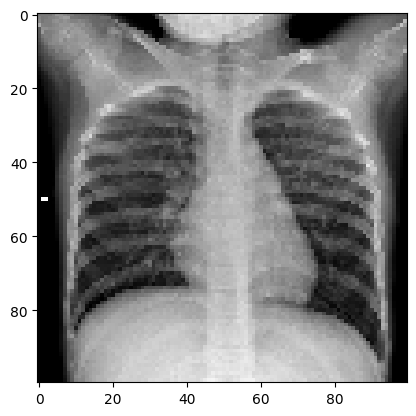

In [ ]:
#image after resize and gray scale
new_array=cv2.resize(img_array, (img_size,img_size))
plt.imshow(new_array,cmap='gray')
plt.show()

In [ ]:
training_data=[]

In [ ]:
def create_training_data():

    for i in CATEGORIES:

        path = os.path.join(DataDir, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):

            try:
                img_array = cv2.imread(
                    os.path.join(path, img),
                    cv2.IMREAD_GRAYSCALE
                )

                new_array = cv2.resize(
                    img_array,
                    (img_size, img_size)
                )

                training_data.append(
                    [new_array, class_num]
                )

            except Exception as e:
                pass

In [ ]:
create_training_data()

In [ ]:
print(len(training_data))

4192


In [ ]:
import random
random.shuffle (training_data)
for sample in training_data[:10]:
    print(sample)

[array([[ 20,  30, 231, ...,  26,  33,  34],
       [ 26,  36, 234, ...,  33,  36,  42],
       [ 33,  39, 234, ...,  35,  40,  51],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 1]
[array([[46, 60, 74, ..., 15, 20, 20],
       [47, 58, 72, ..., 16, 15, 19],
       [39, 55, 68, ..., 16, 15, 17],
       ...,
       [21, 20, 16, ..., 12, 16, 19],
       [17, 21, 20, ..., 12, 14, 16],
       [19, 21, 22, ..., 21, 20, 19]], dtype=uint8), 0]
[array([[ 68,  72,  71, ...,  49,  49,  42],
       [ 70,  75,  78, ...,  51,  45,  39],
       [ 76,  78,  84, ...,  52,  48,  45],
       ...,
       [ 39,  42,  41, ...,  32,  27,  54],
       [ 45,  42,  41, ...,  34,  32,  61],
       [221,  43,  40, ...,  34,  31, 221]], dtype=uint8), 1]
[array([[ 58,  57,  99, ..., 198, 203, 204],
       [ 67,  97, 141, ..., 201, 206, 203],
       [103, 115, 168, ..., 198, 204, 205],
       ...,
      

In [ ]:
X=[]
y=[]

In [ ]:
# spliting the features and labels
for features, label in training_data:
    X.append(features)
    y.append(label)

In [ ]:
print(X[0].reshape(-1,img_size,img_size, 1))

[[[[ 20]
   [ 30]
   [231]
   ...
   [ 26]
   [ 33]
   [ 34]]

  [[ 26]
   [ 36]
   [234]
   ...
   [ 33]
   [ 36]
   [ 42]]

  [[ 33]
   [ 39]
   [234]
   ...
   [ 35]
   [ 40]
   [ 51]]

  ...

  [[  0]
   [  0]
   [  0]
   ...
   [  0]
   [  0]
   [  0]]

  [[  0]
   [  0]
   [  0]
   ...
   [  0]
   [  0]
   [  0]]

  [[  0]
   [  0]
   [  0]
   ...
   [  0]
   [  0]
   [  0]]]]


In [ ]:
y = np.array(y)

In [ ]:
# reshapping the features for making it compatible with tensorflow
X=np.array(X).reshape(-1,img_size,img_size,1)

In [ ]:
#as we do for training data similiarly doing with validation data
validation_data=[]
DataDir_val= r"val/"

In [ ]:
def create_validating_data():

    for i in CATEGORIES:

        path = os.path.join(DataDir_val, i)
        class_num = CATEGORIES.index(i)

        for img in os.listdir(path):

            try:
                img_array = cv2.imread(
                    os.path.join(path, img),
                    cv2.IMREAD_GRAYSCALE
                )

                new_array = cv2.resize(
                    img_array,
                    (img_size, img_size)
                )

                validation_data.append(
                    [new_array, class_num]
                )

            except Exception as e:
                pass

In [ ]:
create_validating_data()
print(len(validation_data))

1040


In [ ]:
import random
random.shuffle (validation_data)
for sample in validation_data[:10]:
  print(sample)

[array([[18, 19, 48, ..., 14, 18, 21],
       [20, 16, 38, ..., 15, 17, 21],
       [18, 12, 34, ..., 14, 17, 20],
       ...,
       [16, 26, 39, ..., 32, 22,  0],
       [17, 26, 36, ..., 33, 25,  0],
       [17, 27, 38, ..., 30, 26,  0]], dtype=uint8), 1]
[array([[108, 119, 113, ...,   0,   0,   0],
       [108, 111, 134, ...,   0,   0,   0],
       [ 94, 112, 122, ...,   0,   0,   0],
       ...,
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0],
       [  0,   0,   0, ...,   0,   0,   0]], dtype=uint8), 0]
[array([[ 5, 18, 18, ..., 23, 20, 11],
       [ 8, 21, 16, ..., 20, 16,  9],
       [ 6, 18, 20, ..., 20, 14,  7],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ...,  0,  0,  0]], dtype=uint8), 1]
[array([[ 1,  0,  0, ..., 70, 26, 17],
       [ 0,  0,  0, ..., 47, 16,  0],
       [ 0,  0,  0, ..., 38, 11,  0],
       ...,
       [ 0,  0,  0, ...,  0,  0,  0],
       [ 0,  0,  0, ..

In [ ]:
X_val=[]
y_val=[]

In [ ]:
for features, label in validation_data:
  X_val.append(features)
  y_val.append(label)

In [ ]:
y_val = np.array(y_val)
X_val=np.array(X_val).reshape(-1, img_size, img_size, 1)

In [ ]:
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense, Dropout, Activation, Flatten
import pickle

In [ ]:
from keras.layers import Conv2D, MaxPooling2D

In [ ]:
#in order to scale it down to 0-1 scale we do this step
X=X/255.0
x_val=X_val/255.0

#feature scaling step
#pixels values range from 0 to 255--- 0 means black and 255 means white

In [ ]:
X.shape

(4192, 100, 100, 1)

In [ ]:
x_val.shape

(1040, 100, 100, 1)

In [ ]:
model = Sequential()

model.add(Conv2D(64, (3, 3), input_shape=X.shape[1:]))
model.add(Activation('relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(.2))  #randomly removes 20 per of the neurons

model.add(Conv2D(128, (3,3)))
model.add(Activation ('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Conv2D (256, (3,3)))
model.add(Activation ('relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Dropout(.2))

model.add(Flatten()) #changes to 1D vector
model.add(Dense(64)) #Learns relationships among extracted features.

model.add(Dropout(.5)) #50 per removed strong protection against overfitting
model.add(Dense(1))
model.add(Activation('sigmoid')) #1 / (1 + e^-x) --range is from 0 to 1

#for example 0.95 → Pneumonia, 0.05 → Normal

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

#num of parans for 1st layer is clac as ((3x3)+1)x64. 3x3 coz num of filters and 64 is num of features
#for next layer it will be ((3x3x64)+1)x128

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 98, 98, 64)     │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 98, 98, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 49, 49, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 47, 47, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 47, 47, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 23, 23, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 21, 21, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 21, 21, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 10, 10, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,638,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,008,193 (7.66 MB)

 Trainable params: 2,008,193 (7.66 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(loss='binary_crossentropy', optimizer='adam',metrics=['accuracy'])

In [ ]:
model.fit(X, y, batch_size=32, epochs=10, validation_data=(x_val, y_val))

Epoch 1/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 260s 2s/step - accuracy: 0.9888 - loss: 0.0294 - val_accuracy: 0.9750 - val_loss: 0.0734
Epoch 2/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9852 - loss: 0.0348 - val_accuracy: 0.9798 - val_loss: 0.0483
Epoch 3/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 237s 2s/step - accuracy: 0.9895 - loss: 0.0283 - val_accuracy: 0.9740 - val_loss: 0.0657
Epoch 4/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 243s 2s/step - accuracy: 0.9926 - loss: 0.0214 - val_accuracy: 0.9760 - val_loss: 0.0719
Epoch 5/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 256s 2s/step - accuracy: 0.9876 - loss: 0.0296 - val_accuracy: 0.9587 - val_loss: 0.1087
Epoch 6/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 268s 2s/step - accuracy: 0.9943 - loss: 0.0168 - val_accuracy: 0.9750 - val_loss: 0.0764
Epoch 7/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 250s 2s/step - accuracy: 0.9905 - loss: 0.0258 - val_accuracy: 0.9750 - val_loss: 0.0609
Epoch 8/10
131/131 ━━━━━━━━━━━━━━━━━━━━ 238s 2s/step - accuracy: 0.9924 - loss: 0.0184 - val_accu

Image

↓

CNN predicts

 ↓

Compare with actual label

 ↓

Calculate loss

 ↓

Adam updates weights

 ↓

Repeat

In [ ]:
#saving the model
model.save(r"/content/drive/MyDrive/model_10.h5")

In [ ]:
#now the testing part
import cv2
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from keras.models import load_model

In [ ]:
CATEGORIES= ["normal", "opacity"]

In [ ]:
#function for preparing the image for predicting the class
def prepare(image):
  img_size=100
#img_array=cv2.imread(image, cv2.IMREAD_GRAYSCALE)
  img=tf.keras.preprocessing.image.load_img(image, color_mode='grayscale', target_size=(img_size,img_size))
  new_array=tf.keras.preprocessing.image.img_to_array(img)
  return new_array.reshape(-1,img_size,img_size, 1)

In [ ]:
model=tf.keras.models.load_model(r"/content/drive/MyDrive/model_10.h5")

In [ ]:
image=r'test/normal/NORMAL2-IM-0110-0001.jpeg'

In [ ]:
prediction=model.predict([prepare(image)/255.0])
print(prediction)
print(round(prediction [0] [0]))
print(CATEGORIES[int(round(prediction[0][0]))])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
[[0.1628865]]
0
normal


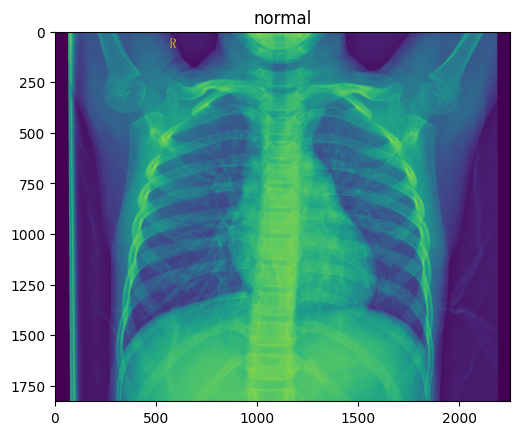

In [ ]:
img=mpimg.imread(image)
imgplot=plt.imshow(img)
plt.title(CATEGORIES [int(prediction [0] [0])])
plt.show()

In [ ]:
#importing necessary libraries
import os
import cv2
import numpy as np
import tensorflow as tf
from keras.models import load_model
# set the path for test data
test_dir = r"test/"
#define categories
CATEGORIES = ["normal", "opacity"]
# set image size
img_size = 100
#load the model
model = load_model(r"/content/drive/MyDrive/model_10.h5")
X_test = []
y_test = []
# loop through the test data directory and extract the images and their labels
for category in CATEGORIES:
  path= os.path.join(test_dir, category)
  class_num = CATEGORIES.index(category)
  for img in os.listdir(path):
    try:
      img_array = cv2.imread(os.path.join(path, img), cv2.IMREAD_GRAYSCALE)
      new_array = cv2.resize(img_array, (img_size, img_size))
      X_test.append(new_array)
      y_test.append(class_num)
    except Exception as e:
      pass
# convert test data to numpy arrays
X_test = np.array(X_test).reshape(-1, img_size, img_size, 1)
y_test = np.array(y_test)

# normalize test data
X_test = X_test / 255.0
# calculate test accuracy
test_loss, test_acc=model.evaluate(X_test, y_test, verbose=2)
# print test accuracy
print('Test accuracy:', test_acc)


20/20 - 19s - 940ms/step - accuracy: 0.7804 - loss: 1.7124
Test accuracy: 0.7804487347602844


**Pre-trained models**
---

In [ ]:
#import necessary libraries
import tensorflow as tf
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras.layers import Dense, Flatten
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
img_size=100
# Clear any previous Keras session
tf.keras.backend.clear_session()
#load the pre-trained model (VGG16)
base_model=VGG16(input_shape=(img_size, img_size,3), include_top=False, weights='imagenet')
#freeze the layers of the pre-trained model
for layer in base_model.layers:
  layer.trainable = False

In [ ]:
# add custom layers for classification
x = Flatten() (base_model.output)
x= Dense (256, activation='relu')(x)
x= Dense (128, activation='relu')(x)
x = Dense (64, activation= 'relu')(x)
predictions=Dense (1, activation='sigmoid')(x)
# create a new model
model = Model(inputs=base_model.input, outputs=predictions)

In [ ]:
# compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])


In [ ]:
# specify the training and validation data directories
train_dir = 'train/'
val_dir = 'val/'

In [ ]:
# define the image generators for training and validation data
train_datagen=ImageDataGenerator (rescale=1./255, shear_range=0.2, zoom_range=0.2, horizontal_flip=True)
val_datagen=ImageDataGenerator (rescale=1./255)

In [ ]:
# create the image generators for training and validation data
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(img_size, img_size), batch_size=64, class_mode='binary')
val_generator = val_datagen.flow_from_directory(val_dir, target_size=(img_size, img_size), batch_size=64, class_mode='binary')
# train the model
model.fit(train_generator, epochs=10, validation_data=val_generator)

Found 4192 images belonging to 2 classes.
Found 1040 images belonging to 2 classes.
Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 716s 11s/step - accuracy: 0.8934 - loss: 0.2462 - val_accuracy: 0.9260 - val_loss: 0.1948
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 697s 11s/step - accuracy: 0.9365 - loss: 0.1568 - val_accuracy: 0.9298 - val_loss: 0.1808
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 690s 10s/step - accuracy: 0.9444 - loss: 0.1415 - val_accuracy: 0.9298 - val_loss: 0.1840
Epoch 4/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 692s 11s/step - accuracy: 0.9511 - loss: 0.1373 - val_accuracy: 0.9375 - val_loss: 0.1575
Epoch 5/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 740s 10s/step - accuracy: 0.9509 - loss: 0.1299 - val_accuracy: 0.9452 - val_loss: 0.1501
Epoch 6/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 685s 10s/step - accuracy: 0.9521 - loss: 0.1209 - val_accuracy: 0.9462 - val_loss: 0.1509
Epoch 7/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 693s 11s/step - accuracy: 0.9628 - loss: 0.1088 - val_accuracy: 0.9471 - val_loss: 0.1513
Epoch 8/10
66/66 ━━━

In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

test_dir = 'test/'

test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

test_loss, test_acc = model.evaluate(test_generator)

print('Test accuracy:', test_acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 81s 4s/step - accuracy: 0.8974 - loss: 0.2981
Test accuracy: 0.8974359035491943


In [33]:
#saving the pre-trained model
model.save(r"/content/drive/MyDrive/custom_pre_trained_model_10.h5")

In [34]:
model = tf.keras.models.load_model("/content/drive/MyDrive/custom_pre_trained_model_10.h5")

In [35]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 100, 100, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 100, 100, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 100, 100, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 50, 50, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 50, 50, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 50, 50, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 25, 25, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 25, 25, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 25, 25, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 12, 12, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 3, 3, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,935,811 (60.79 MB)

 Trainable params: 1,221,121 (4.66 MB)

 Non-trainable params: 14,714,688 (56.13 MB)

 Optimizer params: 2 (12.00 B)

In [36]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Evaluate the model on test data

test_dir = 'test/'

test_datagen = ImageDataGenerator(
    rescale=1./255
)

test_generator = test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=32,
    class_mode='binary',
    shuffle=False,
    color_mode='rgb'
)

test_loss, test_acc = model.evaluate(test_generator)

print('Test accuracy:', test_acc)

Found 624 images belonging to 2 classes.
20/20 ━━━━━━━━━━━━━━━━━━━━ 88s 4s/step - accuracy: 0.8974 - loss: 0.2981
Test accuracy: 0.8974359035491943
